<a href="https://colab.research.google.com/github/saparbayev-azizbek-12/bi-and-ai-talents-dl/blob/main/lesson-26/NameRNN3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import string

eos = '\n'
special_chars = " .,;'-_"
all_letters = string.ascii_letters + special_chars + eos
vocab = {c:i for i, c in enumerate(all_letters)}

In [2]:
import unicodedata

def unicodeToAscii(s):
  return ''.join(
    c for c in unicodedata.normalize('NFD', s)
    if unicodedata.category(c) != 'Mn'
    and c in all_letters
  )


In [3]:
from google.colab import drive

drive.mount('/content/drive/')

Mounted at /content/drive/


In [4]:
import os
import glob

labels = []
names = []
category_names = {}

filenames = glob.glob('/content/drive/MyDrive/names/*.txt')
for filename in filenames:
  lines = open(filename, mode='r', encoding='utf8').read().strip().split('\n')
  label = os.path.splitext(os.path.basename(filename))[0]
  labels.append(label)
  name = [unicodeToAscii(line) for line in lines if unicodeToAscii(line).strip()]
  names.extend(name)
  category_names[label] = name

In [49]:
n_categories = len(labels)
vocab_size = len(vocab)

In [98]:
import torch
import torch.nn as nn

class RNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()
    self.hidden_size = hidden_size
    self.i2h = nn.Linear(n_categories + input_size + hidden_size, hidden_size)
    self.i2o = nn.Linear(n_categories + input_size + hidden_size, output_size)
    self.o2o = nn.Linear(hidden_size + output_size, output_size)
    self.dropout = nn.Dropout(0.1)
    self.softmax = nn.LogSoftmax(dim=-1)

  def forward(self, category, input, hidden):
    input_combined = torch.cat((category, input, hidden), 1)
    hidden = self.i2h(input_combined)
    output = self.i2o(input_combined)
    output_combined = torch.cat((hidden, output), 1)
    output = self.o2o(output_combined)
    output = self.dropout(output)
    output = self.softmax(output)
    return output, hidden

  def _init_layer(self):
    return torch.zeros(1, self.hidden_size)

In [99]:
rnn = RNN(vocab_size, 128, vocab_size)

In [63]:
import random

def random_pair():
  idx = random.randint(0, len(labels) - 1)
  category = labels[idx]
  line = category_names[category]
  line = line[random.randint(0, len(line) - 1)]
  return category, line

In [80]:
def category_to_tensor(category):
  li = labels.index(category)
  tensor = torch.zeros(1, n_categories)
  tensor[0][li] = 1
  return tensor

def input_tensor(line):
  tensor = torch.zeros(len(line), 1, vocab_size)
  for li in range(len(line)):
    tensor[li][0][all_letters.index(line[li])] = 1
  return tensor

def target_tensor(line):
  indices = [all_letters.index(char) for char in (line + eos)[1:]]
  return torch.LongTensor(indices)

In [70]:
print(random_pair())

('Arabic', 'Awad')


In [47]:
def random_traing_pair():
  category, line = random_pair()
  category_tensor = category_to_tensor(category)
  input_line_tensor = input_tensor(line)
  target_line_tensor = target_tensor(line)
  return category_tensor, input_line_tensor, target_line_tensor

In [100]:
criterion = nn.NLLLoss()
optimizer = torch.optim.Adam(rnn.parameters(), lr=0.0005)

def train(category_tensor, input_line_tensor, target_line_tensor):
  target_line_tensor.unsqueeze_(-1)
  hidden = rnn._init_layer()
  rnn.zero_grad()
  loss = 0

  for i in range(input_line_tensor.size(0)):
    output, hidden = rnn.forward(category_tensor, input_line_tensor[i], hidden)
    loss += criterion(output, target_line_tensor[i])

  loss.backward()
  optimizer.step()
  optimizer.zero_grad()


  return output, loss.item() / input_line_tensor.size(0)

In [57]:
import time
import math

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

In [101]:
n_iters = 100000
print_every = 5000
plot_every = 500
all_losses = []
total_loss = 0

start = time.time()

for iter in range(1, n_iters + 1):
    output, loss = train(*random_traing_pair())
    total_loss += loss

    if iter % print_every == 0:
        print('%s (%d %d%%) %.4f' % (timeSince(start), iter, iter / n_iters * 100, loss))

    if iter % plot_every == 0:
        all_losses.append(total_loss / plot_every)
        total_loss = 0

0m 23s (5000 5%) 2.4857
0m 45s (10000 10%) 1.8452
1m 8s (15000 15%) 2.8395
1m 30s (20000 20%) 1.4092
1m 52s (25000 25%) 2.0265
2m 14s (30000 30%) 1.6620
2m 35s (35000 35%) 2.1744
2m 56s (40000 40%) 2.3228
3m 17s (45000 45%) 2.1280
3m 38s (50000 50%) 2.5640
3m 59s (55000 55%) 2.3417
4m 21s (60000 60%) 2.2240
4m 42s (65000 65%) 1.9092
5m 4s (70000 70%) 2.9153
5m 25s (75000 75%) 2.1056
5m 47s (80000 80%) 2.1558
6m 8s (85000 85%) 1.6992
6m 29s (90000 90%) 3.0774
6m 50s (95000 95%) 2.6184
7m 11s (100000 100%) 2.6551


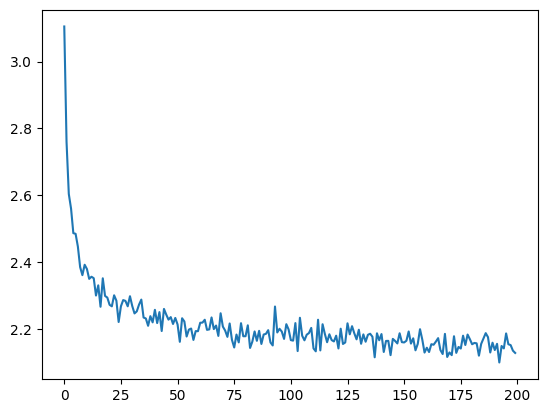

In [102]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(all_losses)

In [103]:
max_length = 20

def sample(category, start_letter='A'):
    with torch.no_grad():
        category_tensor = category_to_tensor(category)
        input = input_tensor(start_letter)
        hidden = rnn._init_layer()

        output_name = start_letter

        for i in range(max_length):
            output, hidden = rnn(category_tensor, input[0], hidden)
            topv, topi = output.topk(1)
            topi = topi[0][0]
            if topi == vocab_size - 1:
                break
            else:
                letter = all_letters[topi]
                output_name += letter
            input = input_tensor(letter)

        return output_name

def samples(category, start_letters='ABC'):
    for start_letter in start_letters:
        print(sample(category, start_letter))

samples('Russian', 'RUS')

samples('German', 'GER')

samples('Spanish', 'SPA')

samples('Chinese', 'CHI')

Romandov
Urbanav
Salonov
Grez
Eshert
Romer
Salvalla
Parra
Alaria
Chu
Han
Ina
